In [ ]:
out_agg = outpatient_m.groupby("Provider").agg({
    "ClaimID": "count",
    "InscClaimAmtReimbursed": ["sum","mean"],
    "ProcedureCount": ["sum","mean"],
    "DiagnosisCount": ["sum","mean"],
    "ChronicCount": ["mean"]
})

out_agg.columns = [
    "Out_ClaimCount","Out_ReimbSum","Out_ReimbMean",
    "Out_ProcSum","Out_ProcMean","Out_DiagSum","Out_DiagMean",
    "Out_ChronicMean"
]


In [ ]:
provider_df = inp_agg.join(out_agg, how="outer")
provider_df = provider_df.join(labels.set_index("Provider"))
provider_df["PotentialFraud"] = provider_df["PotentialFraud"].map({"Yes":1,"No":0})
provider_df.fillna(0, inplace=True)


In [ ]:
provider_df["In_Out_Reimb_Ratio"] = provider_df["Inp_ReimbSum"] / (provider_df["Out_ReimbSum"]+1)
provider_df["Proc_Diag_Ratio_Inp"] = provider_df["Inp_ProcSum"] / (provider_df["Inp_DiagSum"]+1)
provider_df["Proc_Diag_Ratio_Out"] = provider_df["Out_ProcSum"] / (provider_df["Out_DiagSum"]+1)
provider_df["Claim_Ratio_InOut"] = provider_df["Inp_ClaimCount"] / (provider_df["Out_ClaimCount"]+1)


In [ ]:
X = provider_df.drop("PotentialFraud", axis=1)
y = provider_df["PotentialFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear")
lr.fit(X_train_scaled, y_train_res)


LogisticRegression(class_weight='balanced', max_iter=3000, solver='liblinear')

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt.fit(X_train_res, y_train_res)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train_res, y_train_res)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05)
gb.fit(X_train_res, y_train_res)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=300)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=(y==0).sum()/(y==1).sum()
)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", probability=True, class_weight="balanced")
svm.fit(X_train_scaled, y_train_res)


SVC(class_weight='balanced', probability=True)


=======  Logistic Regression  =======
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       981
           1       0.37      0.86      0.51       101

    accuracy                           0.85      1082
   macro avg       0.67      0.85      0.71      1082
weighted avg       0.93      0.85      0.87      1082

ROC AUC: 0.9472956469958922


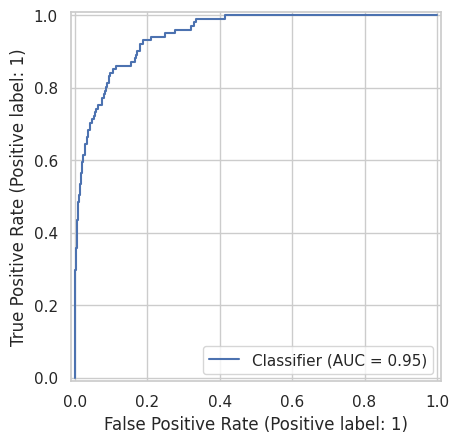

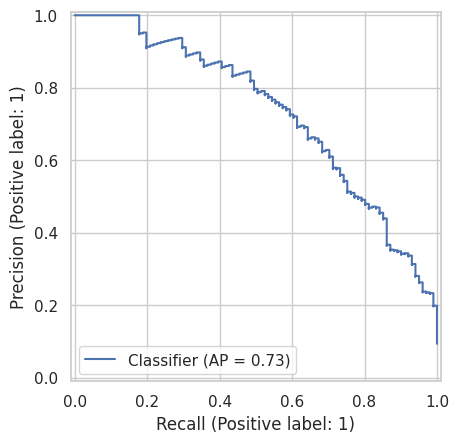


=======  Decision Tree  =======
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       981
           1       0.44      0.64      0.52       101

    accuracy                           0.89      1082
   macro avg       0.70      0.78      0.73      1082
weighted avg       0.91      0.89      0.90      1082

ROC AUC: 0.7799880905521746


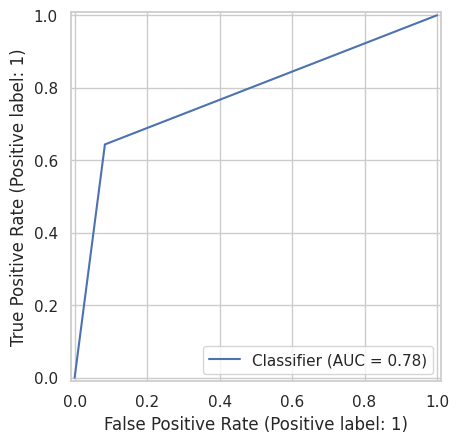

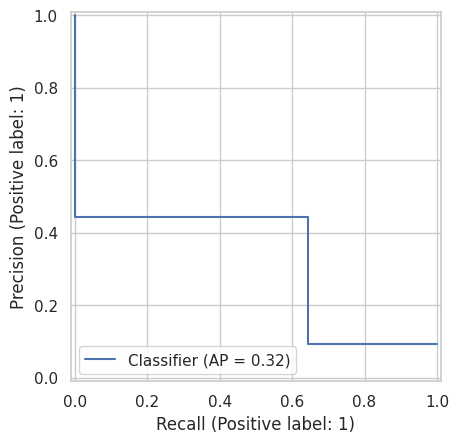


=======  Random Forest  =======
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       981
           1       0.51      0.73      0.60       101

    accuracy                           0.91      1082
   macro avg       0.74      0.83      0.78      1082
weighted avg       0.93      0.91      0.92      1082

ROC AUC: 0.9298856491153703


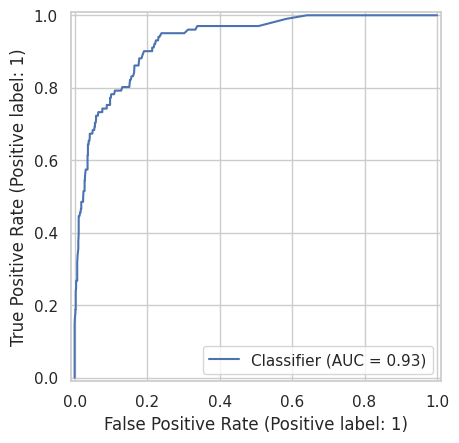

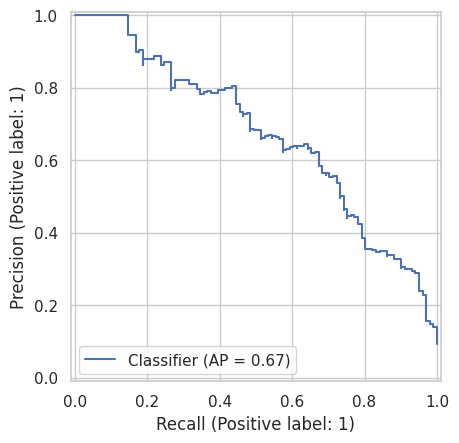


=======  Gradient Boosting  =======
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       981
           1       0.46      0.80      0.58       101

    accuracy                           0.89      1082
   macro avg       0.72      0.85      0.76      1082
weighted avg       0.93      0.89      0.90      1082

ROC AUC: 0.9393627436138109


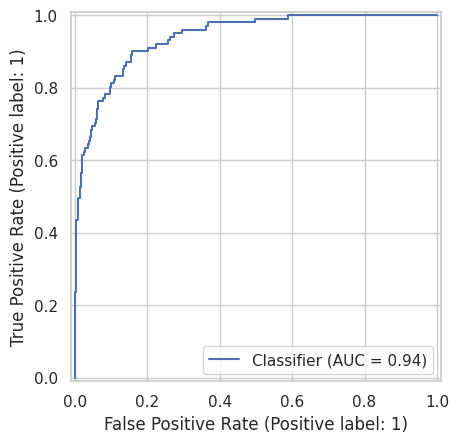

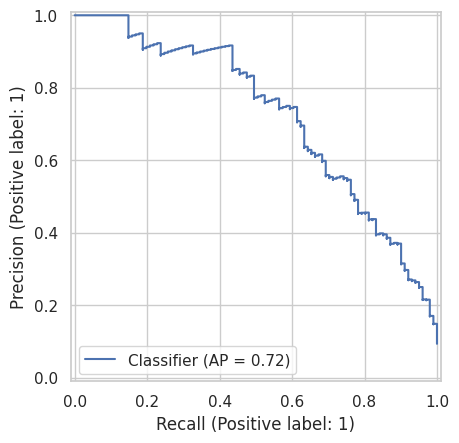


=======  XGBoost  =======
              precision    recall  f1-score   support

           0       0.97      0.92      0.95       981
           1       0.49      0.72      0.58       101

    accuracy                           0.90      1082
   macro avg       0.73      0.82      0.76      1082
weighted avg       0.93      0.90      0.91      1082

ROC AUC: 0.9398371029763527


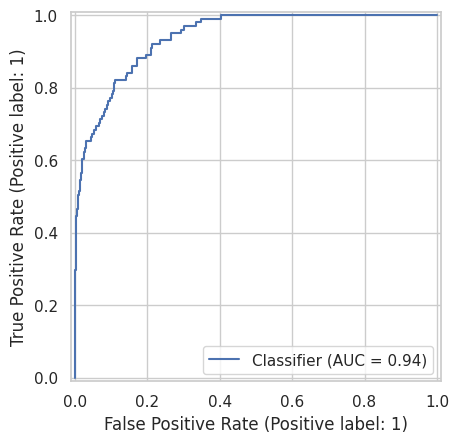

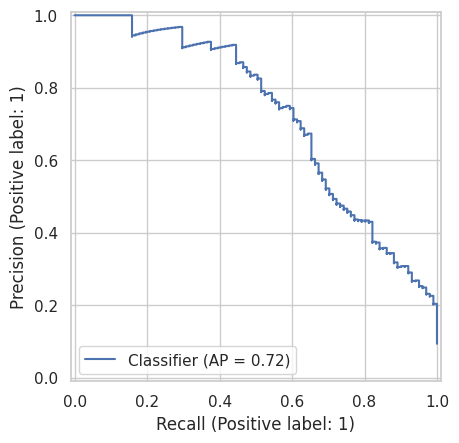


=======  SVM  =======
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       981
           1       0.33      0.86      0.48       101

    accuracy                           0.82      1082
   macro avg       0.66      0.84      0.69      1082
weighted avg       0.92      0.82      0.86      1082

ROC AUC: 0.9272918117499824


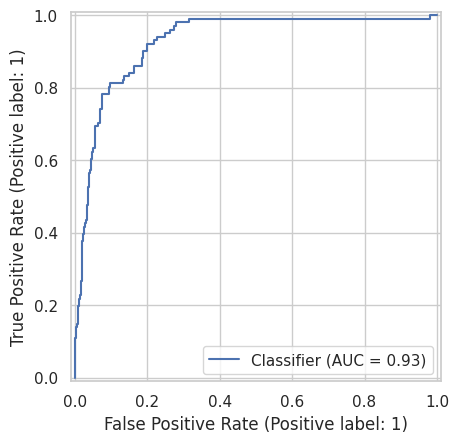

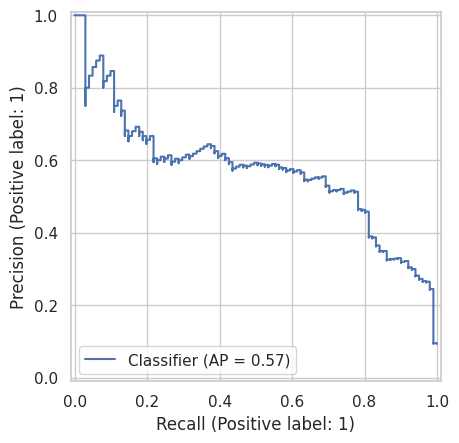

In [ ]:
def evaluate(model, X_test, y_test, name):
    print("\n======= ", name, " =======")

    if name in ["Logistic Regression","SVM"]:
        X_eval = X_test_scaled
    else:
        X_eval = X_test

    y_pred = model.predict(X_eval)
    y_score = model.predict_proba(X_eval)[:,1]

    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_score))

    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_score)
    plt.show()

evaluate(lr, X_test, y_test, "Logistic Regression")
evaluate(dt, X_test, y_test, "Decision Tree")
evaluate(rf, X_test, y_test, "Random Forest")
evaluate(gb, X_test, y_test, "Gradient Boosting")
evaluate(xgb, X_test, y_test, "XGBoost")
evaluate(svm, X_test, y_test, "SVM")


In [ ]:
import joblib

joblib.dump(rf, "../models/random_forest.joblib")
joblib.dump(xgb, "../models/xgboost.joblib")
joblib.dump(lr, "../models/logistic_regression.joblib")
joblib.dump(svm, "../models/svm.joblib")


FileNotFoundError: [Errno 2] No such file or directory: '../models/random_forest.joblib'